In [1]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error

In [3]:
# Load the Diabetes dataset
columns = 'age sex bmi map tc ldl hdl tch ltg glu'.split() # Declare the columns names
diabetes = datasets.load_diabetes() # Call the diabetes dataset from sklearn
df = pd.DataFrame(diabetes.data, columns=columns) # load the dataset as a pandas data frame
y = diabetes.target # define the target variable (dependent variable) as y

In [4]:
df.head()

,age,sex,bmi,map,tc,ldl,hdl,tch,ltg,glu
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [5]:
y[:5]

array([151.,  75., 141., 206., 135.])

In [6]:
# create training and testing vars
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2)
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [7]:
# fit a model
lm = linear_model.LinearRegression()
model = lm.fit(X_train, y_train)
predictions = lm.predict(X_test)

In [8]:
predictions[0:5]

array([ 46.57567041,  97.84597073, 203.32653148, 177.390766  ,
       181.88385075])

Text(0, 0.5, 'Predictions')

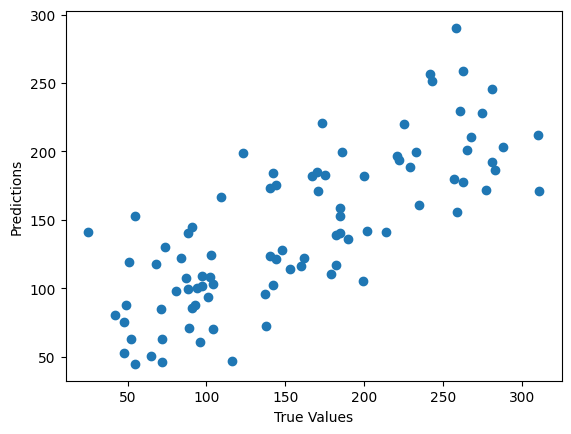

In [9]:
## The line / model
plt.scatter(y_test, predictions)
plt.xlabel('True Values')
plt.ylabel('Predictions')

In [10]:
import numpy as np

In [11]:
print ('Test RMSE:', np.sqrt(mean_squared_error(predictions, y_test)))
print ('Train RMSE:', np.sqrt(mean_squared_error(lm.predict(X_train), y_train)))

Test RMSE: 50.97956798241632
Train RMSE: 54.315753742971665


# Cross Validation

In [12]:
from sklearn.model_selection import KFold # import KFold
X = np.array([[1, 2], [3, 4], [1, 2], [3, 4]]) # create an array
y = np.array([1, 2, 3, 4]) # Create another array
kf = KFold(n_splits=2) # Define the split - into 2 folds 
kf.get_n_splits(X) # returns the number of splitting iterations in the cross-validator

2

In [13]:
print(kf)

KFold(n_splits=2, random_state=None, shuffle=False)


In [14]:
for train_index, test_index in kf.split(X):
    print('TRAIN:', train_index, 'TEST:', test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

TRAIN: [2 3] TEST: [0 1]
TRAIN: [0 1] TEST: [2 3]


### LOOCV

In [15]:
from sklearn.model_selection import LeaveOneOut 
X = np.array([[1, 2], [3, 4], [1, 2], [3, 4]]) # create an array
y = np.array([1, 2, 3, 4]) # Create another array
loo = LeaveOneOut()
loo.get_n_splits(X)


for train_index, test_index in loo.split(X):
    print('TRAIN:', train_index, 'TEST:', test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

TRAIN: [1 2 3] TEST: [0]
TRAIN: [0 2 3] TEST: [1]
TRAIN: [0 1 3] TEST: [2]
TRAIN: [0 1 2] TEST: [3]


In [16]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn import metrics

In [17]:


X = df.drop(['bmi'], axis = 1)
y = df['bmi']

# Perform 6-fold cross validation
scores = cross_val_score(model, X, y, cv=6)
print ('Cross-validated scores:', scores)

Cross-validated scores: [0.31253328 0.29201251 0.26364366 0.32325558 0.32358976 0.27379977]


In [18]:
cross_val_predict(model, X, y, cv=10)

array([ 0.00784173, -0.05179206, -0.00944117,  0.0154719 , -0.0023196 ,
       -0.0328554 , -0.02983306,  0.00569014, -0.01033948,  0.01503296,
       -0.00731739, -0.0347682 , -0.01969323,  0.00039968, -0.03693148,
        0.03091781,  0.01401178,  0.02542261, -0.00120563, -0.02003986,
       -0.00338185, -0.02795759, -0.01031926,  0.03276146, -0.01093396,
       -0.00086107, -0.01838413, -0.00417926, -0.02063698,  0.00660437,
       -0.00607683, -0.0441191 ,  0.01906815, -0.03712601, -0.03832005,
       -0.04713405,  0.01664096, -0.01390537,  0.04288068, -0.01506585,
        0.02990631, -0.04052104, -0.00303159, -0.0386177 ,  0.01261952,
       -0.0048561 , -0.01803047, -0.01950354, -0.03090813,  0.01884216,
        0.00690871,  0.00413723, -0.0017054 ,  0.02324268, -0.009442  ,
       -0.03954891,  0.01414809, -0.04848898, -0.04178214,  0.00419276,
       -0.0367102 ,  0.01224675, -0.05606534, -0.01745431, -0.01974066,
        0.03610713,  0.01090101, -0.00612652, -0.01514774, -0.00

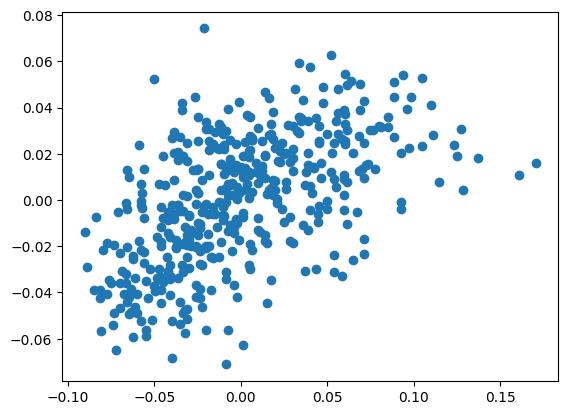

In [19]:
# Make cross validated predictions
predictions = cross_val_predict(model, X, y, cv=10)
plt.scatter(y, predictions)

In [20]:
np.mean((y-predictions)**2)

np.float64(0.0015681476423430717)

In [21]:
np.sqrt(mean_squared_error(y,predictions))

np.float64(0.039599843968670785)

# Feature Scaling

In [22]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
  
# Read Data from CSV 
data = pd.read_csv('/home/blueberry/Downloads/regression.csv') 
data.head() 

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Position,Jersey Number,Contract Valid Until,Height,Weight
0,L. Messi,31,Argentina,94,94,FC Barcelona,110500000.0,€565K,RF,10.0,2021,5'7,159lbs
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000000.0,€405K,ST,7.0,2022,6'2,183lbs
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500000.0,€290K,LW,10.0,2022,5'9,150lbs
3,De Gea,27,Spain,91,93,Manchester United,72000000.0,€260K,GK,1.0,2020,6'4,168lbs
4,K. De Bruyne,27,Belgium,91,92,Manchester City,102000000.0,€355K,RCM,7.0,2023,5'11,154lbs


In [23]:
y = data['Value']

In [24]:
data = data.drop(['Name', 'Nationality', 'Club', 'Wage', 'Position', 'Weight', 'Height', 'Contract Valid Until', 'Value'], axis = 1)

In [25]:
data.head()

,Age,Overall,Potential,Jersey Number
0,31,94,94,10.0
1,33,94,94,7.0
2,26,92,93,10.0
3,27,91,93,1.0
4,27,91,92,7.0


In [26]:
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.2)

#### MinMaxScaler

In [27]:
# Initialise the Scaler and Fit
norm = MinMaxScaler().fit(X_train)

In [28]:
pd.DataFrame(columns = X_train.columns, data = norm.transform(X_train))

,Age,Overall,Potential,Jersey Number
0,0.344828,0.541667,0.543478,0.061224
1,0.620690,0.229167,0.195652,0.306122
2,0.206897,0.520833,0.652174,0.204082
3,0.241379,0.270833,0.391304,0.387755
4,0.068966,0.208333,0.521739,0.448980
...,...,...,...,...
14320,0.172414,0.416667,0.630435,0.153061
14321,0.068966,0.187500,0.434783,0.214286
14322,0.655172,0.645833,0.630435,0.051020
14323,0.586207,0.458333,0.434783,0.285714


In [29]:
pd.DataFrame(columns = X_test.columns, data = norm.transform(X_test))

,Age,Overall,Potential,Jersey Number
0,0.275862,0.500000,0.630435,0.020408
1,0.620690,0.479167,0.456522,0.132653
2,0.275862,0.312500,0.326087,0.030612
3,0.586207,0.625000,0.608696,0.061224
4,0.241379,0.375000,0.456522,0.153061
...,...,...,...,...
3577,0.310345,0.687500,0.695652,0.061224
3578,0.310345,0.520833,0.565217,0.040816
3579,0.482759,0.416667,0.391304,0.193878
3580,0.310345,0.354167,0.434783,0.153061


### Standard Scaler

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
# Initialise the Scaler and Fit
norm = StandardScaler().fit(X_train)

In [38]:
X_train_scaled_df = pd.DataFrame(columns = X_train.columns, data = norm.transform(X_train))

In [ ]:
X_test_scaled_df = pd.DataFrame(columns = X_test.columns, data = norm.transform(X_test))

,Age,Overall,Potential,Jersey Number
0,-0.232500,0.534660,0.912521,-1.038730
1,1.916941,0.390276,-0.389960,-0.350710
2,-0.232500,-0.764798,-1.366822,-0.976182
3,1.701997,1.400966,0.749711,-0.788541
4,-0.447444,-0.331646,-0.389960,-0.225615
...,...,...,...,...
3577,-0.017556,1.834119,1.400952,-0.788541
3578,-0.017556,0.679045,0.424091,-0.913635
3579,1.057165,-0.042877,-0.878391,0.024574
3580,-0.017556,-0.476030,-0.552771,-0.225615


# tasks

###### try applying this scalers to any dataset and check the regression results

In [52]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

stdscale = StandardScaler()
X_train_scaled = stdscale.fit_transform(X_train)
X_test_scaled = stdscale.transform(X_test)

model_unscaled = LinearRegression().fit(X_train, y_train)
model_scaled = LinearRegression().fit(X_train_scaled, y_train)

print('Unscaled R2:', r2_score(y_test, model_unscaled.predict(X_test)))
print('Scaled R2:', r2_score(y_test, model_scaled.predict(X_test_scaled)))

print('Unscaled RMSE:', np.sqrt(mean_squared_error(y_test, model_unscaled.predict(X_test))))
print('Scaled RMSE:', np.sqrt(mean_squared_error(y_test, model_scaled.predict(X_test_scaled))))

minmaxscale = MinMaxScaler()
X_train_scaled = minmaxscale.fit_transform(X_train)
X_test_scaled = minmaxscale.transform(X_test)

model_unscaled = LinearRegression().fit(X_train, y_train)
model_scaled = LinearRegression().fit(X_train_scaled, y_train)

print('Unscaled R2:', r2_score(y_test, model_unscaled.predict(X_test)))
print('Scaled R2:', r2_score(y_test, model_scaled.predict(X_test_scaled)))

print('Unscaled RMSE:', np.sqrt(mean_squared_error(y_test, model_unscaled.predict(X_test))))
print('Scaled RMSE:', np.sqrt(mean_squared_error(y_test, model_scaled.predict(X_test_scaled))))

Unscaled R2: 0.5676053371101628
Scaled R2: 0.5676053371101627
Unscaled RMSE: 0.7388939362571806
Scaled RMSE: 0.7388939362571808
Unscaled R2: 0.5676053371101628
Scaled R2: 0.5676053371101628
Unscaled RMSE: 0.7388939362571806
Scaled RMSE: 0.7388939362571806


Text(0.5, 1.0, 'After')

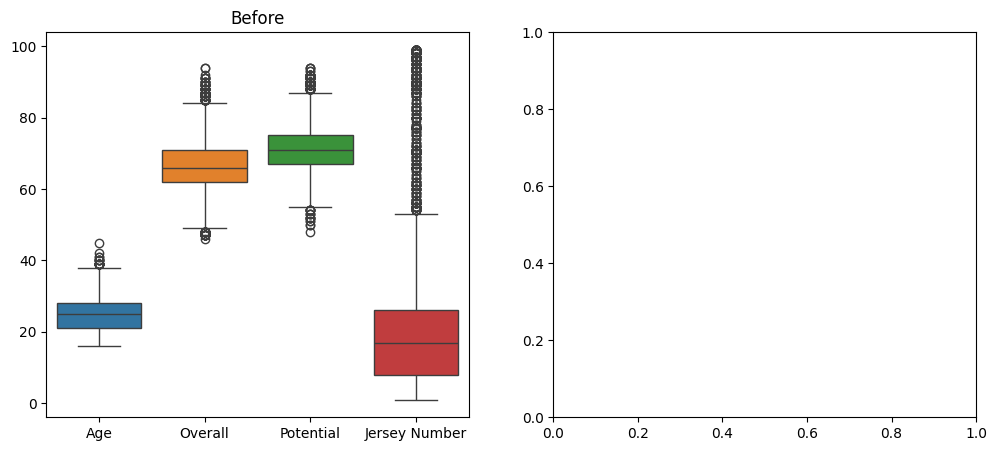

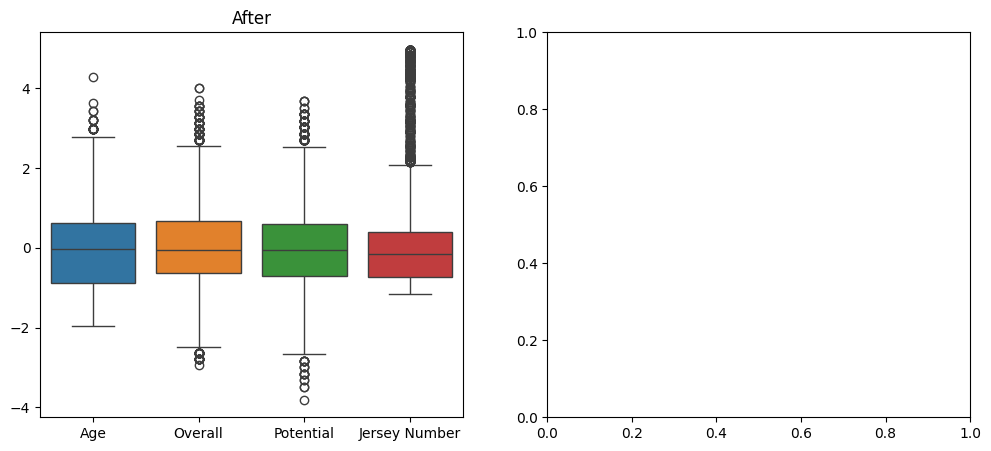

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=X_train, ax=ax1)
ax1.set_title('Before')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=X_train_scaled_df, ax=ax1)
ax1.set_title('After')

In [40]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


# One Hot Encoding

In [34]:
data = pd.read_csv('/home/blueberry/Downloads/regression.csv')

In [35]:
data.head()

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Position,Jersey Number,Contract Valid Until,Height,Weight
0,L. Messi,31,Argentina,94,94,FC Barcelona,110500000.0,€565K,RF,10.0,2021,5'7,159lbs
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000000.0,€405K,ST,7.0,2022,6'2,183lbs
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500000.0,€290K,LW,10.0,2022,5'9,150lbs
3,De Gea,27,Spain,91,93,Manchester United,72000000.0,€260K,GK,1.0,2020,6'4,168lbs
4,K. De Bruyne,27,Belgium,91,92,Manchester City,102000000.0,€355K,RCM,7.0,2023,5'11,154lbs


In [36]:
pd.get_dummies(data[['Age', 'Club']])

,Age,Club_ SSV Jahn Regensburg,Club_1. FC Heidenheim 1846,Club_1. FC Kaiserslautern,Club_1. FC Köln,Club_1. FC Magdeburg,Club_1. FC Nürnberg,Club_1. FC Union Berlin,Club_1. FSV Mainz 05,Club_AC Ajaccio,...,Club_Wycombe Wanderers,Club_Yeni Malatyaspor,Club_Yeovil Town,Club_Yokohama F. Marinos,Club_Zagłębie Lubin,Club_Zagłębie Sosnowiec,Club_Çaykur Rizespor,Club_Örebro SK,Club_Östersunds FK,Club_Śląsk Wrocław
0,31,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,33,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,26,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,27,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,27,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17902,19,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17903,19,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17904,16,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17905,17,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# tasks

###### try applying OHE to any column(s) and check the regression results

In [56]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Region'] = np.random.choice(['North', 'South', 'East', 'West'], size=len(df))
y=data.target

X_num = df.drop(['Region'], axis=1)
model_num = LinearRegression().fit(X_num, y)
r2_num = model_num.score(X_num, y)

ct = ColumnTransformer([('ohe', OneHotEncoder(drop='first'), ['Region'])], remainder='passthrough')
X_ohe = ct.fit_transform(df)
model_ohe = LinearRegression().fit(X_ohe, y)
r2_ohe = model_ohe.score(X_ohe, y)

print(f'R2 with numeric features: {r2_num}')
print(f'R2 with one-hot encoded features: {r2_ohe}')



R2 with numeric features: 0.606232685199805
R2 with one-hot encoded features: 0.6063690562181078
